Cybersecurity/Fraud Detection ML Capstone Workflow

1. Import Libraries

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

import warnings
warnings.filterwarnings('ignore')

2. Load Dataset

In [2]:
import pandas as pd
import glob
import os

# Folder containing CICIDS CSV files
path = r"C:\Users\bhuva\Downloads\MachineLearningCSV\MachineLearningCVE"

# Get all CSV files
files = glob.glob(os.path.join(path, "*.csv"))

# Load and combine datasets
df = pd.concat(
    [pd.read_csv(file) for file in files],
    ignore_index=True
)

# Clean column names
df.columns = df.columns.str.strip()

print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

df.head()

Dataset Shape:
(5661486, 79)

Columns:
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Co

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [3]:
df['Label'].value_counts()

Label
BENIGN                        4546194
DoS Hulk                       462146
PortScan                       317860
DDoS                           256054
DoS GoldenEye                   20586
FTP-Patator                     15876
SSH-Patator                     11794
DoS slowloris                   11592
DoS Slowhttptest                10998
Bot                              3932
Web Attack � Brute Force         3014
Web Attack � XSS                 1304
Infiltration                       72
Web Attack � Sql Injection         42
Heartbleed                         22
Name: count, dtype: int64

In [4]:
df.to_csv(
    r"C:\Users\bhuva\Downloads\CICIDS2017_combined.csv",
    index=False
)

Dataset Overview

In [5]:
# Dataset shape

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

# Column names

df.columns.tolist()

Rows: 5661486
Columns: 79


['Destination Port',
 'Flow Duration',
 'Total Fwd Packets',
 'Total Backward Packets',
 'Total Length of Fwd Packets',
 'Total Length of Bwd Packets',
 'Fwd Packet Length Max',
 'Fwd Packet Length Min',
 'Fwd Packet Length Mean',
 'Fwd Packet Length Std',
 'Bwd Packet Length Max',
 'Bwd Packet Length Min',
 'Bwd Packet Length Mean',
 'Bwd Packet Length Std',
 'Flow Bytes/s',
 'Flow Packets/s',
 'Flow IAT Mean',
 'Flow IAT Std',
 'Flow IAT Max',
 'Flow IAT Min',
 'Fwd IAT Total',
 'Fwd IAT Mean',
 'Fwd IAT Std',
 'Fwd IAT Max',
 'Fwd IAT Min',
 'Bwd IAT Total',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Bwd IAT Max',
 'Bwd IAT Min',
 'Fwd PSH Flags',
 'Bwd PSH Flags',
 'Fwd URG Flags',
 'Bwd URG Flags',
 'Fwd Header Length',
 'Bwd Header Length',
 'Fwd Packets/s',
 'Bwd Packets/s',
 'Min Packet Length',
 'Max Packet Length',
 'Packet Length Mean',
 'Packet Length Std',
 'Packet Length Variance',
 'FIN Flag Count',
 'SYN Flag Count',
 'RST Flag Count',
 'PSH Flag Count',
 'ACK Flag Count',
 'UR

3. Exploratory Data Analysis (EDA)

Missing Values

In [6]:
missing = df.isnull().sum()

missing[missing > 0]

Flow Bytes/s    2716
dtype: int64

Dataset Statistics

In [7]:
df.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,5.661486e+06,5.661486e+06,5.661486e+06,5.661486e+06,5.661486e+06,5.661486e+06,5.661486e+06,5.661486e+06,5.661486e+06,5.661486e+06,...,5.661486e+06,5.661486e+06,5.661486e+06,5.661486e+06,5.661486e+06,5.661486e+06,5.661486e+06,5.661486e+06,5.661486e+06,5.661486e+06
mean,8.071483e+03,1.478566e+07,9.361160e+00,1.039377e+01,5.493024e+02,1.616264e+04,2.075999e+02,1.871366e+01,5.820194e+01,6.891013e+01,...,5.418218e+00,-2.741688e+03,8.155132e+04,4.113412e+04,1.531825e+05,5.829582e+04,8.316037e+06,5.038439e+05,8.695752e+06,7.920031e+06
std,1.828363e+04,3.365374e+07,7.496727e+02,9.973882e+02,9.993588e+03,2.263088e+06,7.171848e+02,6.033934e+01,1.860911e+02,2.811871e+02,...,6.364256e+02,1.084989e+06,6.485999e+05,3.933815e+05,1.025825e+06,5.770922e+05,2.363008e+07,4.602984e+06,2.436689e+07,2.336342e+07
min,0.000000e+00,-1.300000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,-5.368707e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.300000e+01,1.550000e+02,2.000000e+00,1.000000e+00,1.200000e+01,0.000000e+00,6.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00,...,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,8.000000e+01,3.131600e+04,2.000000e+00,2.000000e+00,6.200000e+01,1.230000e+02,3.700000e+01,2.000000e+00,3.400000e+01,0.000000e+00,...,1.000000e+00,2.400000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,4.430000e+02,3.204858e+06,5.000000e+00,4.000000e+00,1.870000e+02,4.820000e+02,8.100000e+01,3.600000e+01,5.000000e+01,2.616295e+01,...,2.000000e+00,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,6.553500e+04,1.200000e+08,2.197590e+05,2.919220e+05,1.290000e+07,6.554530e+08,2.482000e+04,2.325000e+03,5.940857e+03,7.125597e+03,...,2.135570e+05,1.380000e+02,1.100000e+08,7.420000e+07,1.100000e+08,1.100000e+08,1.200000e+08,7.690000e+07,1.200000e+08,1.200000e+08


Class Distribution

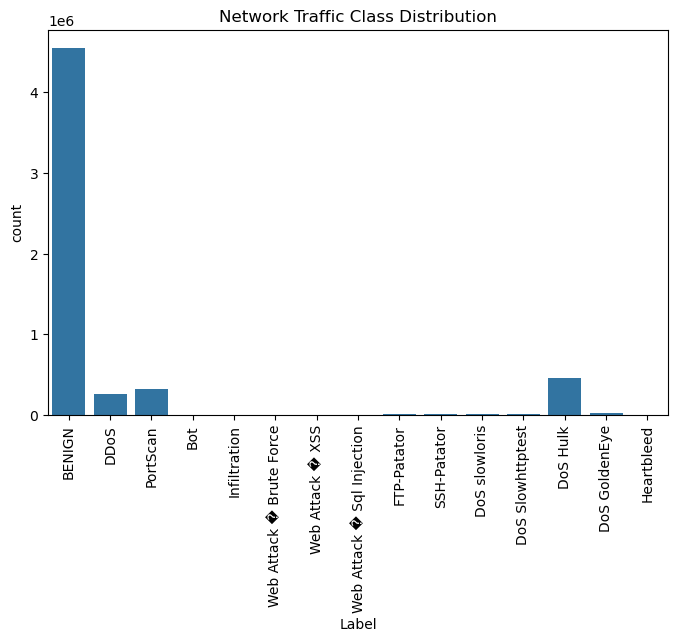

In [8]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Label',
    data=df
)

plt.xticks(rotation=90)
plt.title("Network Traffic Class Distribution")

plt.show()

Target Check

In [9]:
df['Label'].value_counts()

Label
BENIGN                        4546194
DoS Hulk                       462146
PortScan                       317860
DDoS                           256054
DoS GoldenEye                   20586
FTP-Patator                     15876
SSH-Patator                     11794
DoS slowloris                   11592
DoS Slowhttptest                10998
Bot                              3932
Web Attack � Brute Force         3014
Web Attack � XSS                 1304
Infiltration                       72
Web Attack � Sql Injection         42
Heartbleed                         22
Name: count, dtype: int64

4. Data Preparation
Convert Target into Binary Classification

Normal traffic = 0
Attack traffic = 1

In [27]:
df['Label'] = df['Label'].apply(
    lambda x: 0 if x == 'BENIGN' else 1
)


df['Label'].value_counts()

Label
1    5661486
Name: count, dtype: int64

Define Features and Target

In [28]:
X = df.drop('Label', axis=1)

y = df['Label']

Handle Missing / Infinite Values

In [12]:
X = X.replace(
    [np.inf, -np.inf],
    np.nan
)


X = X.fillna(0)

Train/Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


print(X_train.shape)
print(X_test.shape)

(3963040, 78)
(1698446, 78)


5. Feature Scaling

In [14]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

6. Model Training

Random Forest Model

In [15]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)


model.fit(
    X_train_scaled,
    y_train
)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Predictions

In [16]:
y_pred = model.predict(
    X_test_scaled
)


y_prob = model.predict_proba(
    X_test_scaled
)[:,1]

7. Model Evaluation


Accuracy

In [17]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

accuracy

0.9993982734805816

Precision/Recall/F1

In [18]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1363858
           1       1.00      1.00      1.00    334588

    accuracy                           1.00   1698446
   macro avg       1.00      1.00      1.00   1698446
weighted avg       1.00      1.00      1.00   1698446



Confusion Matrix

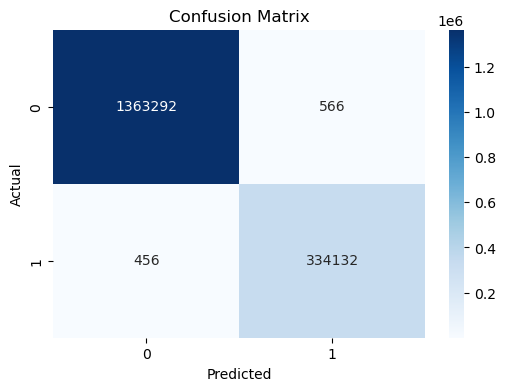

In [19]:
cm = confusion_matrix(
    y_test,
    y_pred
)


plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

ROC Curve and AUC

AUC: 0.9999236018961398


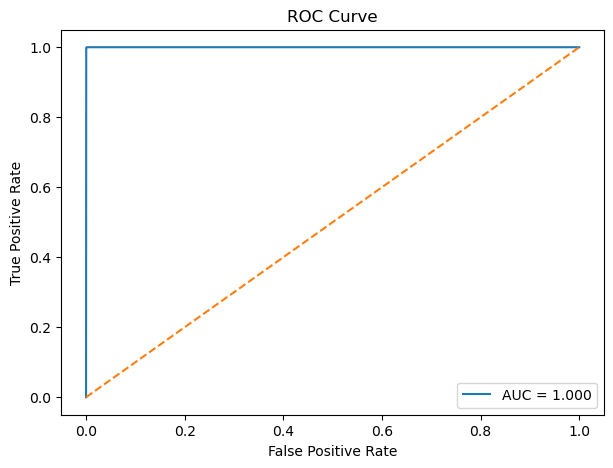

In [20]:
auc = roc_auc_score(
    y_test,
    y_prob
)

print("AUC:", auc)


fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)


plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.3f}"
)


plt.plot(
    [0,1],
    [0,1],
    '--'
)


plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

8. Feature Importance

In [21]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": model.feature_importances_

})


importance = importance.sort_values(
    by="Importance",
    ascending=False
)


importance.head(10)

,Feature,Importance
39,Max Packet Length,0.064427
42,Packet Length Variance,0.059567
54,Avg Bwd Segment Size,0.058919
41,Packet Length Std,0.054529
0,Destination Port,0.053736
52,Average Packet Size,0.052698
10,Bwd Packet Length Max,0.041549
13,Bwd Packet Length Std,0.039085
5,Total Length of Bwd Packets,0.030985
63,Subflow Fwd Bytes,0.029462


Visualization

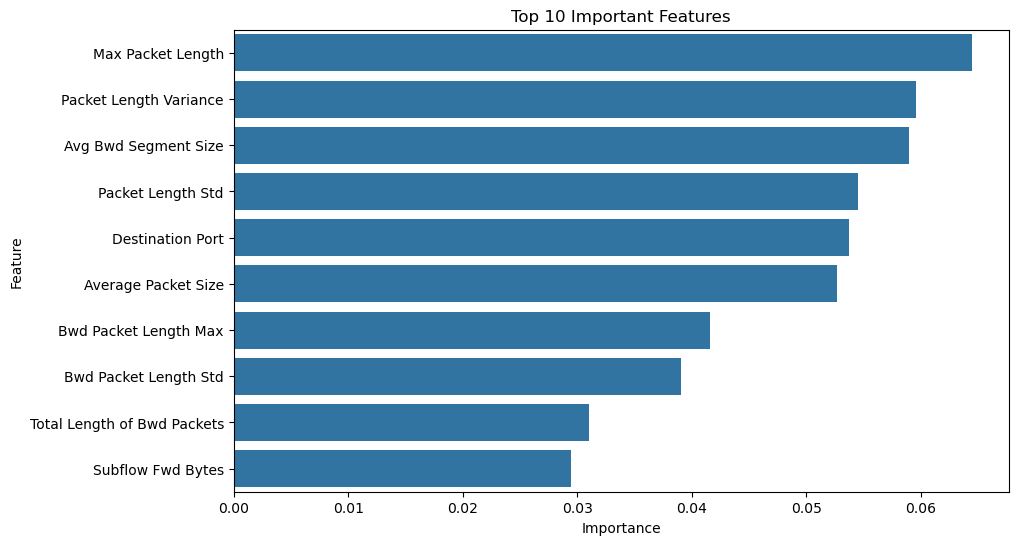

In [22]:
plt.figure(figsize=(10,6))


sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)


plt.title(
    "Top 10 Important Features"
)


plt.show()

9. Interpretation / Reflection

The Random Forest model was able to identify patterns between normal and malicious network traffic. 
The model achieved strong classification performance; however, accuracy alone is not enough because cybersecurity datasets often contain class imbalance.

The confusion matrix showed false positives and false negatives, which represent incorrect classifications. False negatives are especially important because they represent missed attacks.

Important features helped identify network behaviors associated with suspicious activity. Future improvements include balancing the dataset using SMOTE, hyperparameter tuning, and testing deep learning approaches.

In [23]:
import os

project_path = os.getcwd()
print(project_path)

c:\Users\bhuva\Downloads


In [30]:
import os
import pandas as pd

# Create folder path
processed_path = "C:\\Users\\bhuva\\OneDrive\\Documents\\GitHub\\cybersecurity-capstone-Team2-June2026\\data\\processed"

# Make sure folder exists
os.makedirs(processed_path, exist_ok=True)

# Save dataframe
df.to_csv(
    os.path.join(processed_path, "cleaned_dataset.csv"),
    index=False
)

print("Saved successfully!")

Saved successfully!


In [33]:
import joblib
import os

os.makedirs("C:\\Users\\bhuva\\OneDrive\\Documents\\GitHub\\cybersecurity-capstone-Team2-June2026\\models", exist_ok=True)

joblib.dump(
    model,
    "C:\\Users\\bhuva\\OneDrive\\Documents\\GitHub\\cybersecurity-capstone-Team2-June2026\\models\\random_forest.pkl"
)

print("Model exported")

Model exported


In [32]:
import matplotlib.pyplot as plt
import os

os.makedirs("C:\\Users\\bhuva\\OneDrive\\Documents\\GitHub\\cybersecurity-capstone-Team2-June2026\\reports\\figures", exist_ok=True)

plt.savefig(
    "C:\\Users\\bhuva\\OneDrive\\Documents\\GitHub\\cybersecurity-capstone-Team2-June2026\\reports\\figures\\confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

In [34]:
os.makedirs(
    "../models",
    exist_ok=True
)


joblib.dump(
    model,
    "C:\\Users\\bhuva\\OneDrive\\Documents\\GitHub\\cybersecurity-capstone-Team2-June2026\\models\\random_forest_model.pkl"
)


joblib.dump(
    scaler,
    "C:\\Users\\bhuva\\OneDrive\\Documents\\GitHub\\cybersecurity-capstone-Team2-June2026\\models\\scaler.pkl"
)


print("Model saved")

Model saved
